<a href="https://colab.research.google.com/github/Har1ly/Project1/blob/main/Copy_of_New_Zealand_Food_Price_Index_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'selected-price-indexes-june-2026.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/selected-price-indexes-june-2026.csv


In [5]:
import pandas as pd

file_path = "/content/drive/MyDrive/selected-price-indexes-june-2026.csv"

df = pd.read_csv(file_path)

print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Number of rows and columns:
(59519, 10)

Column names:
['Series_reference', 'Period', 'Data_value', 'STATUS', 'UNITS', 'Subject', 'Group', 'Series_title_1', 'Series_title_2', 'Series_title_3']

First 5 rows:


,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
0,CPIM.SE901,1960.01,45.923461,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
1,CPIM.SE901,1960.02,45.498637,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
2,CPIM.SE901,1960.03,45.116296,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
3,CPIM.SE901,1960.04,45.158779,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
4,CPIM.SE901,1960.05,45.286226,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN


In [6]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe(include="all").T)

Data Types:
Series_reference     object
Period              float64
Data_value          float64
STATUS               object
UNITS                object
Subject              object
Group                object
Series_title_1       object
Series_title_2       object
Series_title_3       object
dtype: object

Missing Values:
Series_reference        0
Period                  0
Data_value             91
STATUS                  0
UNITS                   0
Subject                 0
Group                   0
Series_title_1          0
Series_title_2      57868
Series_title_3      57868
dtype: int64

Duplicated Rows:
0

Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Series_reference,59519,237,CPIM.SE901,798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Period,59519.0,NaN,NaN,NaN,2014.03821,9.686038,1960.01,2010.04,2015.12,2021.03,2026.06
Data_value,59428.0,NaN,NaN,NaN,384.095431,508.50028,-2.0,3.43,8.88,905.775076,3222.0
STATUS,59519,2,FINAL,54635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UNITS,59519,3,Dollars,34708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subject,59519,1,Consumers Price Index - CPI,59519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Group,59519,15,Food Price Index Selected Monthly Weighted Ave...,34708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Series_title_1,59519,214,Seasonally adjusted,4904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Series_title_2,1651,1,Actual rentals for housing,1651,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Series_title_3,1651,2,Flow,1416,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
clean_df = df.copy()

clean_df = clean_df.drop(columns=["Series_title_2", "Series_title_3"])

clean_df = clean_df.dropna(subset=["Data_value"])

clean_df["Period"] = pd.to_datetime(
    clean_df["Period"].astype(str),
    format="%Y.%m"
)

print("Cleaned dataset shape:")
print(clean_df.shape)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nFirst 5 rows:")
display(clean_df.head())

Cleaned dataset shape:
(59428, 8)

Missing values after cleaning:
Series_reference    0
Period              0
Data_value          0
STATUS              0
UNITS               0
Subject             0
Group               0
Series_title_1      0
dtype: int64

Duplicate rows:
69

First 5 rows:


,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1
0,CPIM.SE901,1960-01-01,45.923461,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food
1,CPIM.SE901,1960-02-01,45.498637,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food
2,CPIM.SE901,1960-03-01,45.116296,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food
3,CPIM.SE901,1960-04-01,45.158779,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food
4,CPIM.SE901,1960-05-01,45.286226,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food


In [8]:
clean_df = clean_df.drop_duplicates()

clean_df = clean_df.reset_index(drop=True)

print("Dataset shape after removing duplicates:")
print(clean_df.shape)

print("\nRemaining duplicate rows:")
print(clean_df.duplicated().sum())

Dataset shape after removing duplicates:
(59359, 8)

Remaining duplicate rows:
0


In [9]:
group_counts = clean_df["Group"].value_counts()

print("Number of records by group:")
display(group_counts)

Number of records by group:


,count
Group,
Food Price Index Selected Monthly Weighted Average Prices for New Zealand,34585
Food Price Index Level 4 Sections for New Zealand,6217
Food Price Index Level 3 Classes for New Zealand,5036
"Food Price Index Level 3 Classes for New Zealand, Seasonally adjusted",3371
Food Price Index Level 2 Subgroups for New Zealand,2024
"Food Price Index for New Zealand, percentage change",1579
CPI Level 3 Classes for New Zealand,1562
"Food Price Index Level 2 Subgroups for New Zealand, Seasonally adjusted",1203
CPI Monthly Rents (Broad Regions),1180


/tmp/ipykernel_544/3508463518.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


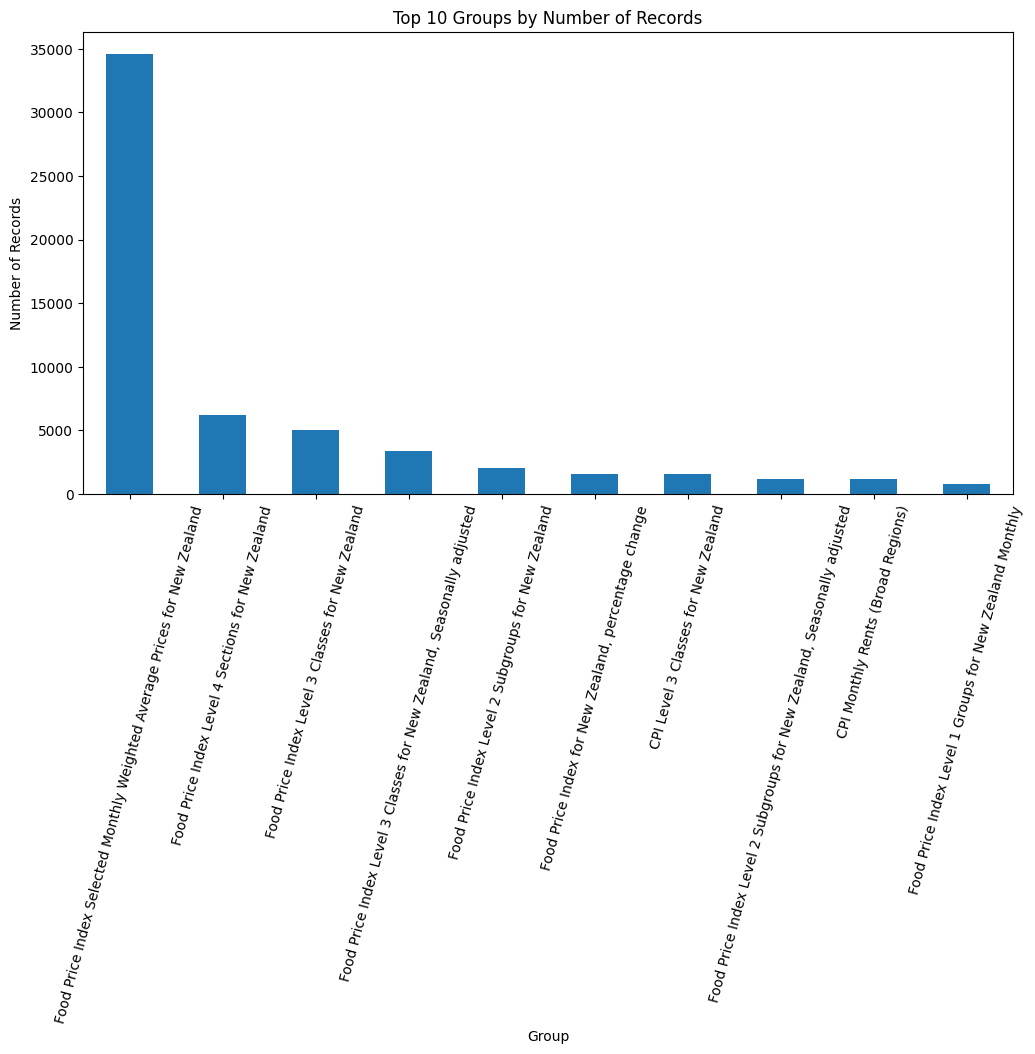

In [10]:
import matplotlib.pyplot as plt

# Select the top 10 groups
top_groups = clean_df["Group"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_groups.plot(kind="bar")

plt.title("Top 10 Groups by Number of Records")
plt.xlabel("Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

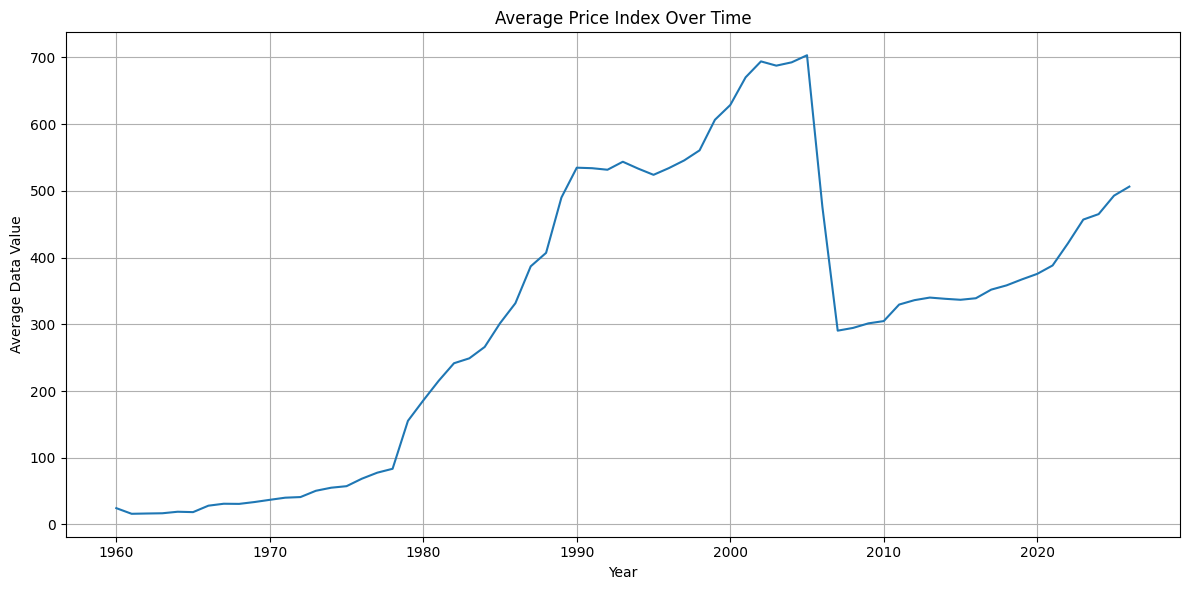

In [11]:
yearly_avg = clean_df.groupby(
    clean_df["Period"].dt.year
)["Data_value"].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_avg.index, yearly_avg.values)

plt.title("Average Price Index Over Time")
plt.xlabel("Year")
plt.ylabel("Average Data Value")
plt.grid(True)
plt.tight_layout()
plt.show()

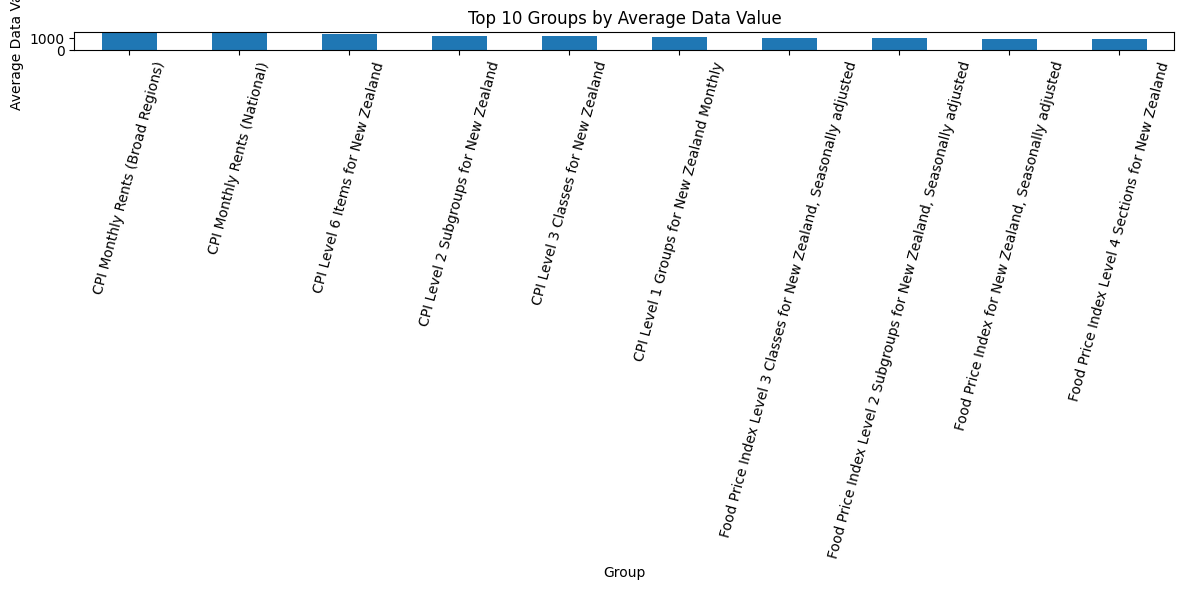

In [12]:
group_avg = clean_df.groupby("Group")["Data_value"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
group_avg.plot(kind="bar")

plt.title("Top 10 Groups by Average Data Value")
plt.xlabel("Group")
plt.ylabel("Average Data Value")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

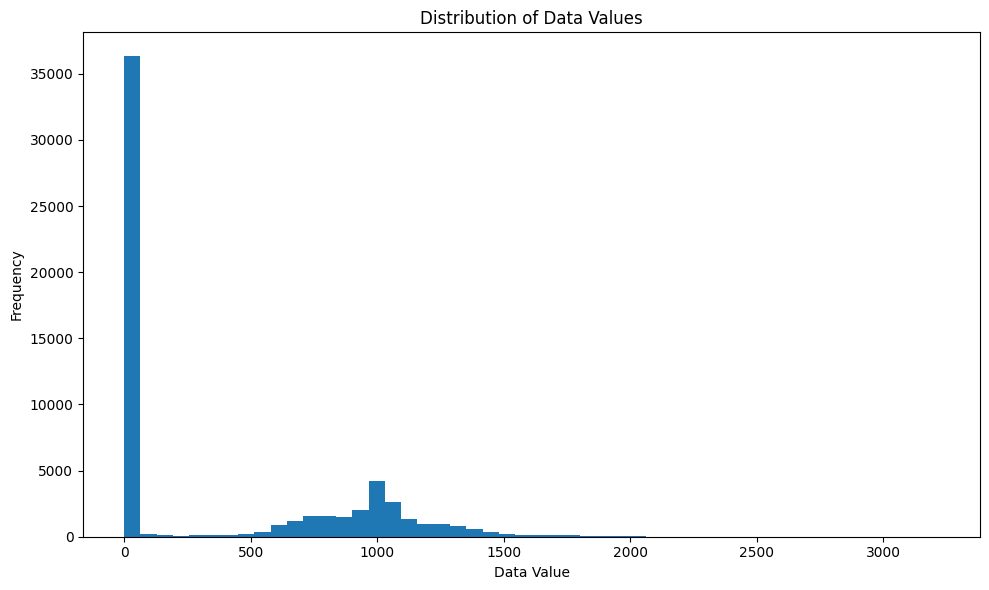

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(clean_df["Data_value"], bins=50)

plt.title("Distribution of Data Values")
plt.xlabel("Data Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
print("Minimum Data Value:", clean_df["Data_value"].min())
print("Maximum Data Value:", clean_df["Data_value"].max())
print("Average Data Value:", clean_df["Data_value"].mean())
print("Median Data Value:", clean_df["Data_value"].median())

Minimum Data Value: -2.0
Maximum Data Value: 3222.0
Average Data Value: 384.1645132413629
Median Data Value: 8.89


In [15]:
model_df = clean_df.copy()

model_df["Year"] = model_df["Period"].dt.year
model_df["Month"] = model_df["Period"].dt.month

X = model_df[["Year", "Month"]]
y = model_df["Data_value"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Year,Month
0,1960,1
1,1960,2
2,1960,3
3,1960,4
4,1960,5



Target:


,Data_value
0,45.923461
1,45.498637
2,45.116296
3,45.158779
4,45.286226


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 47487
Testing samples: 11872


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Model Evaluation
-----------------
MAE: 468.7123687486705
RMSE: 507.94120773192464
R²: 0.002322249126091691


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 47487
Testing samples: 11872


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[366.11922795 366.59919931 405.80995769 372.90544261 377.48737578
 374.84753326 406.76990043 417.41809121 374.82532808 400.4858623 ]


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Model Evaluation
-----------------
MAE: 468.7123687486705
RMSE: 507.94120773192464
R²: 0.002322249126091691


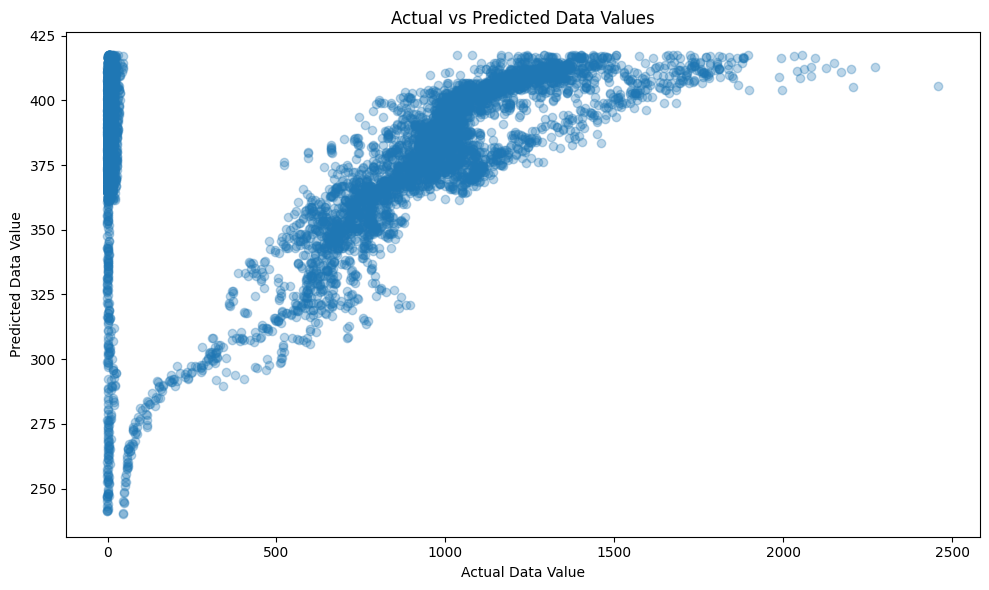

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Data Value")
plt.ylabel("Predicted Data Value")
plt.title("Actual vs Predicted Data Values")

plt.tight_layout()
plt.show()

In [24]:
print("===== Key Findings =====")

print("Number of records:", len(clean_df))
print("Number of groups:", clean_df["Group"].nunique())
print("Minimum value:", clean_df["Data_value"].min())
print("Maximum value:", clean_df["Data_value"].max())
print("Average value:", round(clean_df["Data_value"].mean(), 2))
print("Median value:", clean_df["Data_value"].median())
print("Model R²:", round(r2, 4))
print("Model MAE:", round(mae, 2))
print("Model RMSE:", round(rmse, 2))

===== Key Findings =====
Number of records: 59359
Number of groups: 15
Minimum value: -2.0
Maximum value: 3222.0
Average value: 384.16
Median value: 8.89
Model R²: 0.0023
Model MAE: 468.71
Model RMSE: 507.94


In [25]:
clean_file_path = "/content/drive/MyDrive/cleaned_price_indexes.csv"

clean_df.to_csv(clean_file_path, index=False)

print("Cleaned dataset saved successfully!")
print(clean_file_path)

Cleaned dataset saved successfully!
/content/drive/MyDrive/cleaned_price_indexes.csv


In [26]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results_file_path = "/content/drive/MyDrive/model_predictions.csv"

results.to_csv(results_file_path, index=False)

print("Model predictions saved successfully!")

Model predictions saved successfully!


In [27]:
print("===== FINAL PROJECT FINDINGS =====")

print("Total records after cleaning:", len(clean_df))
print("Number of groups:", clean_df["Group"].nunique())

print("Minimum Data Value:", clean_df["Data_value"].min())
print("Maximum Data Value:", clean_df["Data_value"].max())
print("Average Data Value:", round(clean_df["Data_value"].mean(), 2))
print("Median Data Value:", clean_df["Data_value"].median())

print("\nModel Performance:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

===== FINAL PROJECT FINDINGS =====
Total records after cleaning: 59359
Number of groups: 15
Minimum Data Value: -2.0
Maximum Data Value: 3222.0
Average Data Value: 384.16
Median Data Value: 8.89

Model Performance:
MAE: 468.71
RMSE: 507.94
R²: 0.0023


Project Findings

The dataset contained 59,519 records and 10 columns before cleaning. During the cleaning process, 91 records with missing Data_value values were removed, and columns with a very high percentage of missing values were excluded. A total of 69 duplicate records were also removed, resulting in 59,359 clean records and 8 columns.

The analysis showed considerable variation in Data_value across the different price index groups and time periods. The dataset covers observations from 1960 to 2026, providing a long historical view of price index data for New Zealand.

A simple Linear Regression model was developed using Year and Month as input features to predict Data_value. The model achieved an MAE of 468.71, an RMSE of 507.94, and an R² of 0.0023. The very low R² indicates that Year and Month alone are not sufficient to accurately explain the variation in Data_value across all groups.

Therefore, the model provides a useful baseline, but a more advanced model with additional features such as Group, Series_reference, and other relevant variables would likely provide better predictions.

Conclusion

This project demonstrated an end-to-end data analysis workflow, including data loading, data cleaning, exploratory analysis, visualization, machine learning, model evaluation, and presentation of findings. The dataset was successfully cleaned by handling missing values and duplicate records. Several visualizations were created to identify patterns and trends in the price index data. A simple Linear Regression model was also implemented and evaluated. Although the model had limited predictive performance, it provided a useful baseline and demonstrated the complete data science workflow.